<a href="https://colab.research.google.com/github/kaonashithank1022/data-analysis-basic-kadai/blob/main/text/10%E7%AB%A0_%E5%9B%9E%E5%B8%B0%E3%81%AE%E6%89%8B%E6%B3%95%E3%82%92%E5%AD%A6%E3%81%BC%E3%81%86_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

カリフォルニアの住宅に関するデータ（所得、築年数、部屋数など）から、住宅価格を予測したい。
住宅価格は、主にどの要素から影響を受けているか知りたい。


住宅価格を予測する計算式を決定する。
住宅に関する各要素が、住宅価格に与える影響度合いについても見解を述べる。

In [ ]:
#必要なライブラリのインポート
import numpy as np
import pandas as pd
import seaborn as sns

!pip install japanize-matplotlib -q
import japanize_matplotlib

In [ ]:

#データセットの準備
#ファイルを、Pandasのread_csv関数で読み込み
df = pd.read_csv('/content/california_housing_cleansing.csv')
df.head()

#取り込むデータの列名がブランクの場合、その列は自動的に「Unnamed:数字」という列名が割り振られる
#「Unnamed: 0」の列を削除
df = df.drop(columns = ['Unnamed: 0'])
df.head()

#「california_housing_cleansing.csv」の全18572行のデータが取り込まれているか確認
df.shape


(18572, 8)

In [ ]:
#元のデータフレームから '住宅価格' の列だけを取り除いた新しいデータフレームを作成
#説明変数Xは住宅価格以外の全列のデータ、目的変数yは住宅価格のデータ
X = df.drop(columns=['住宅価格']).to_numpy()
y = df['住宅価格'].to_numpy()

#train_test_split関数をインポート
from sklearn.model_selection import train_test_split

#train_test_split関数によって、比率7:3で学習データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

#データ数を確認
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(13000, 7) (5572, 7) (13000,) (5572,)


In [ ]:
#予測モデルの学習
#linear_modelモジュールのLinearRegressionクラスをインポート
from sklearn.linear_model import LinearRegression

#ンポートしたLinearRegressionクラスをインスタンス化して、modelという変数に代入
model = LinearRegression()

#.fit() メソッドを使って学習させる
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#予測モデルの評価
#scoreメソッドを利用して、学習データを用いた決定係数を出力
model.score(X_train, y_train)

#scoreメソッドを利用して、テストデータを用いた決定係数を出力
model.score(X_test, y_test)

0.5752388860477959

In [ ]:
#予測
#darray形式でX_newという変数に保持させる
X_new = np.array([[8, 41, 500, 37, -120, 1, 0.2],
                  [2, 10, 2000, 38, -122, 1.5, 0.5],
                  [1, 25, 1000, 38, -121, 2, 1]])

model.predict(X_new)

print(model.coef_)
print(model.intercept_)

[ 4.08110906e-01  6.92312594e-03  1.70628946e-05 -4.04061927e-01
 -4.10380169e-01 -2.08486703e-01  1.69589529e+00]
-34.74453851952332


[ 4.08110906e-01  6.92312594e-03  1.70628946e-05 -4.04061927e-01
 -4.10380169e-01 -2.08486703e-01  1.69589529e+00]
-34.74453851952332


<Axes: >

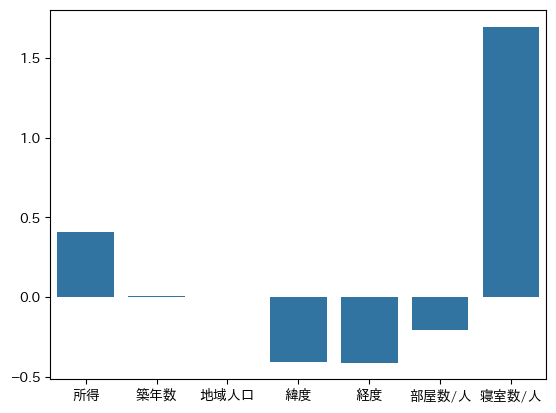

In [ ]:

#設定したゴールに対する考察

#住宅価格を予測する計算式を決定する
print(model.coef_)
print(model.intercept_)

#住宅に関する各要素が、住宅価格に与える影響度合いについても見解を述べる
sns.barplot(x = ['所得', '築年数', '地域人口', '緯度', '経度', '部屋数/人', '寝室数/人'], y=model.coef_)

df.describe()